In [1]:
import os
import gc
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')


def image_transform():
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
        transforms.Resize((224,224)),
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform()
    image = read_image(path)
    image = transform(image)
    return image

In [4]:
def compute_similarity(image_path, embeddings, model):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)


# Returns ([float], [str])
# tuple of similarity values and image paths (not sorted)
def calculate_similarity(model, embeddings, embeddings_paths, image_path):
    similarities = compute_similarity(image_path, embeddings, model).cpu().numpy().flatten()
    return similarities, embeddings_paths

In [5]:
embeddings = torch.load('../models/logos_embedding_tuned.pt')
embeddings_paths = pd.read_csv('../models/logos_embedding_tuned.csv', header=None, index_col=None)[0].tolist()
len(embeddings_paths)

100000

In [6]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
model.eval()
load_model(model, '../models/similarity.safetensors')
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

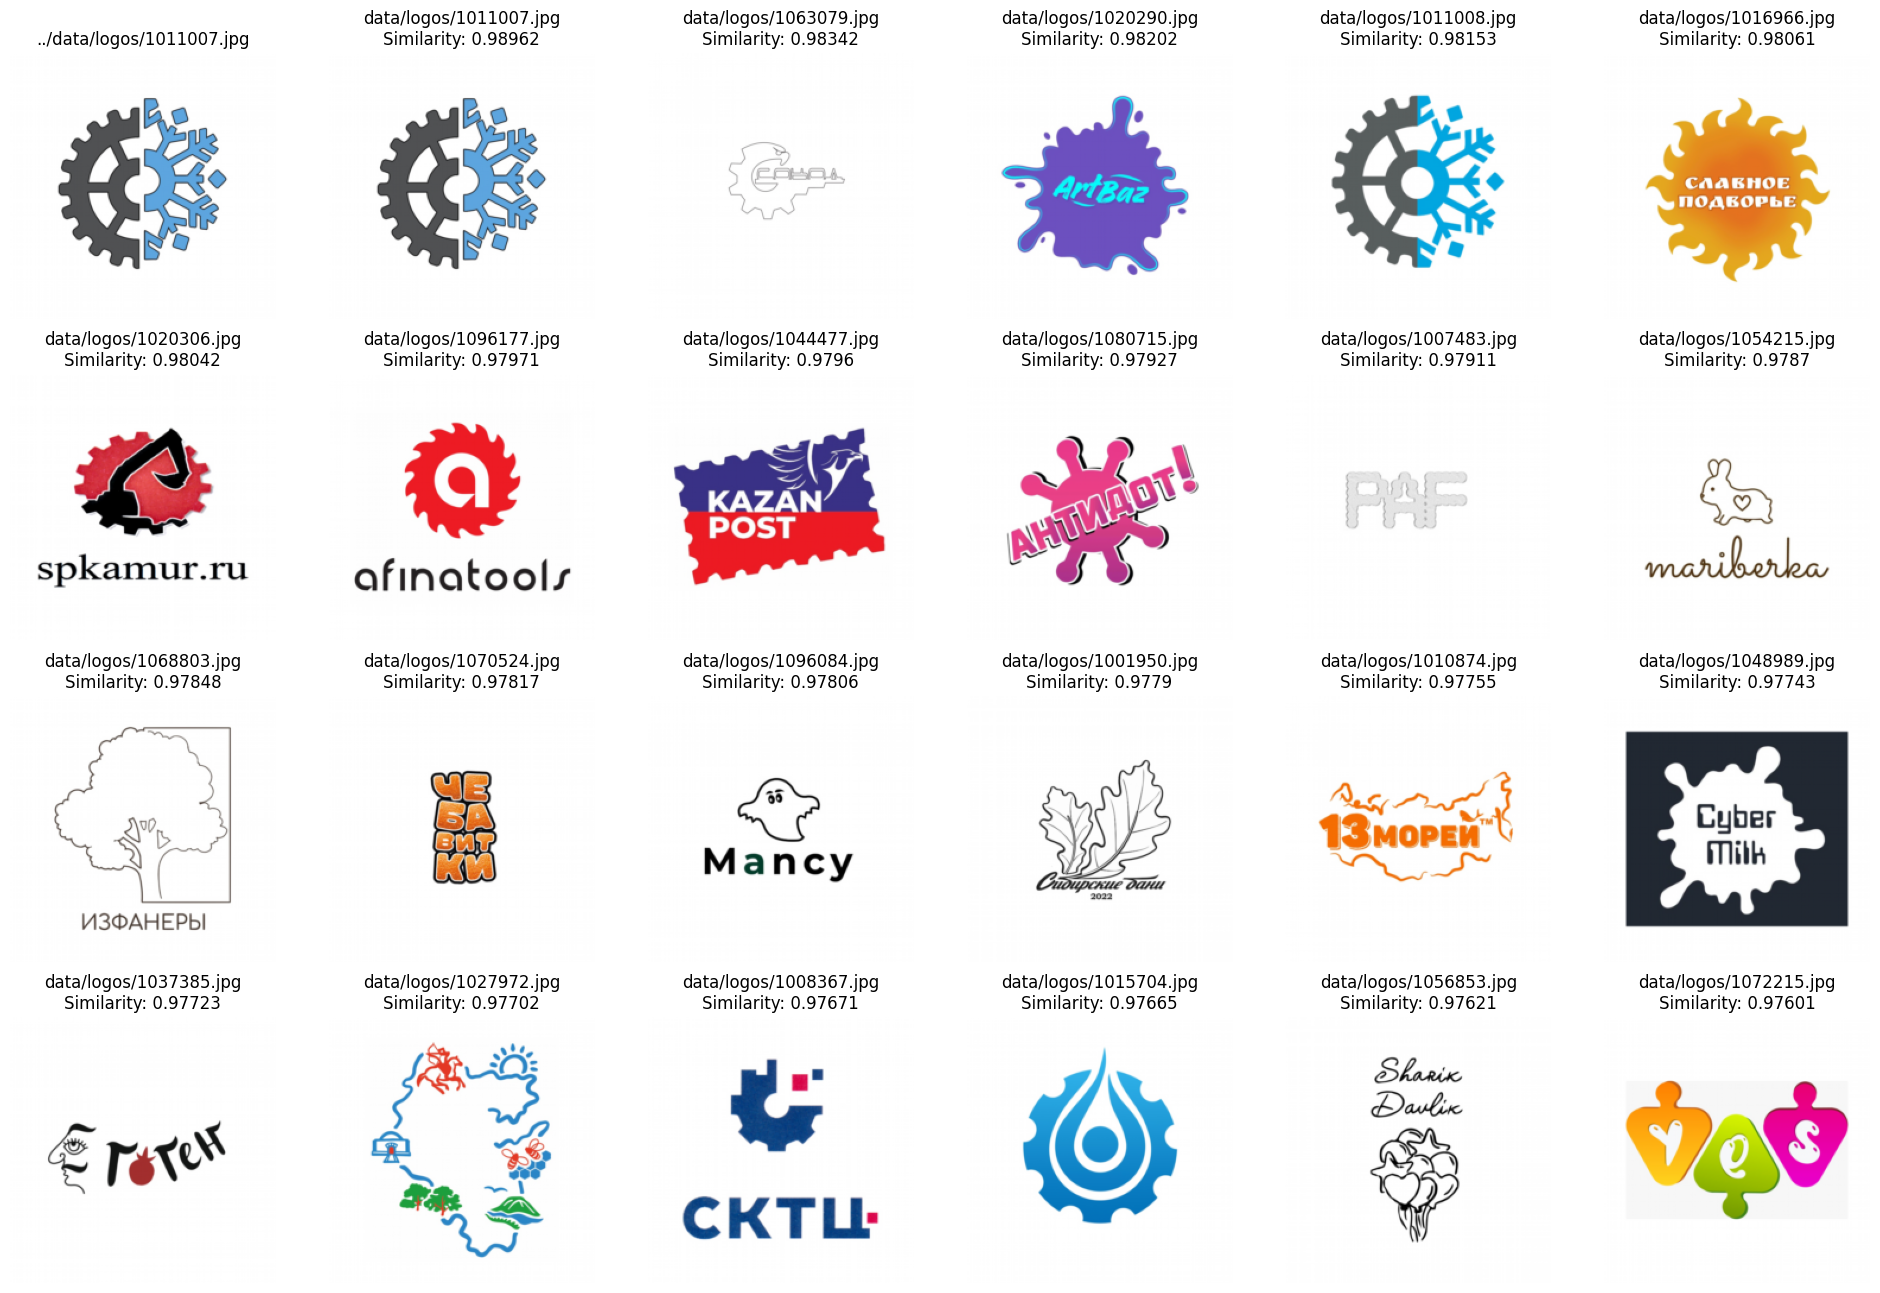

In [7]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
#img_path = '../data/logos/1014250.jpg' # duck sitting at a table
img_path = '../data/logos/1011007.jpg'

similarities = compute_similarity(img_path, embeddings, model).cpu().numpy().flatten()
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = embeddings_paths[idx]
            img = load_image('../' + path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()

In [43]:
import ast
import multiprocessing as mp
from color_analysis_tool import ImageAnalyzer, ImageInfo
from scipy.stats import wasserstein_distance_nd

def analyse_colors(image_path, palette_size):
    analyzer = ImageAnalyzer()
    return analyzer.analyze_image(image_path, max_colors=palette_size)


# For some reason, the function from matplotlib doesn't work
def rgb_to_hsv(arr):
    """
    Convert an array of float RGB values (in the range [0, 1]) to HSV values.

    Parameters
    ----------
    arr : (..., 3) array-like
       All values must be in the range [0, 1]

    Returns
    -------
    (..., 3) `~numpy.ndarray`
       Colors converted to HSV values in range [0, 1]
    """
    arr = np.asarray(arr)

    # check length of the last dimension, should be _some_ sort of rgb
    if arr.shape[-1] != 3:
        raise ValueError("Last dimension of input array must be 3; "
                         f"shape {arr.shape} was found.")

    in_shape = arr.shape
    arr = np.array(
        arr,
        dtype=np.promote_types(arr.dtype, np.float32),  # Don't work on ints.
        ndmin=2,  # In case input was 1D.
    )

    out = np.zeros_like(arr)
    arr_max = arr.max(-1)
    # Check if input is in the expected range
    if np.any(arr_max > 1):
        raise ValueError(
            "Input array must be in the range [0, 1]. "
            f"Found a maximum value of {arr_max.max()}"
        )

    if arr.min() < 0:
        raise ValueError(
            "Input array must be in the range [0, 1]. "
            f"Found a minimum value of {arr.min()}"
        )

    ipos = arr_max > 0
    delta = np.ptp(arr, -1)
    s = np.zeros_like(delta)
    s[ipos] = delta[ipos] / arr_max[ipos]
    ipos = delta > 0
    # red is max
    idx = (arr[..., 0] == arr_max) & ipos
    out[idx, 0] = (arr[idx, 1] - arr[idx, 2]) / delta[idx]
    # green is max
    idx = (arr[..., 1] == arr_max) & ipos
    out[idx, 0] = 2. + (arr[idx, 2] - arr[idx, 0]) / delta[idx]
    # blue is max
    idx = (arr[..., 2] == arr_max) & ipos
    out[idx, 0] = 4. + (arr[idx, 0] - arr[idx, 1]) / delta[idx]

    out[..., 0] = (out[..., 0] / 6.0) % 1.0
    out[..., 1] = s
    out[..., 2] = arr_max

    return out.reshape(in_shape)


# Convert analysis result to a tuple of values/weights
def to_distribution(info: ImageInfo):
    values = []
    weights = []
    for color in info.colors:
        (r,g,b) = color.rgb
        values.append([r / 255.0, g / 255.0, b / 255.0])
        weights.append(color.frequency)
    return (values, weights)


def similarity_fn(args):
    colors, weights, other_colors, other_weights = args
    distance = wasserstein_distance_nd(colors, other_colors, weights, other_weights)
    return 1.0 / (1.0 + distance)


def convert_embeddings(embeddings, palette_size):
    embed_colors = []
    embed_weights = []
    for _, row in tqdm(embeddings.iterrows(), total=len(embeddings)):
        colors, weights = ast.literal_eval(row[0])
        missing = (palette_size - len(colors))
        embed_colors.append(colors + [[0.0,0.0,0.0]] * missing)
        embed_weights.append(weights + [0.0] * missing)
        assert len(embed_colors[-1]) == palette_size
        assert len(embed_weights[-1]) == palette_size
    return embed_colors, embed_weights


# Use this with preconverted embeddings and color analysis
def compute_similarity_preconverted(image_colors, image_weights, embed_colors, embed_weights):
    with mp.Pool(mp.cpu_count()) as pool:
        tasks = [
            (image_colors, image_weights, other_c, other_w) 
            for other_c, other_w in zip(embed_colors, embed_weights)
        ]
        it = pool.imap(similarity_fn, tasks, chunksize=10)
        cembeddings = list(tqdm(it, total=len(embed_colors)))
    return cembeddings

In [39]:
color_embeddings = pd.read_csv('../models/logos_embedding_tuned_colors.csv', header=None, index_col=None)
palette_size = 8

print("Converting embeddings...")
embed_colors, embed_weights = convert_embeddings(color_embeddings, palette_size)

Converting embeddings...


100%|██████████| 100000/100000 [00:10<00:00, 9900.99it/s]


In [53]:
def compute_similarity_combined(image_path, weights):
    info = analyse_colors(image_path, palette_size)
    (image_colors, image_weights) = to_distribution(info)

    # Compute individual metrics
    basic_sim = compute_similarity(image_path, embeddings, model).cpu().numpy().flatten()
    color_sim = compute_similarity_preconverted(image_colors, image_weights, embed_colors, embed_weights)

    # Combine metrics
    assert len(basic_sim) == len(color_sim)
    k = 3 # the factor of the color curve, bigger number - less impact at lower values
    m = 0.1 # extra multiplier to reduce max impact of the color similarity
    similarities = []
    for i in range(len(basic_sim)):
        b = basic_sim[i]
        c = color_sim[i]
        f = c ** k * m
        value = b * (1.0 - f) + f * c
        similarities.append(value)

    return similarities

100%|██████████| 100000/100000 [00:21<00:00, 4598.79it/s]


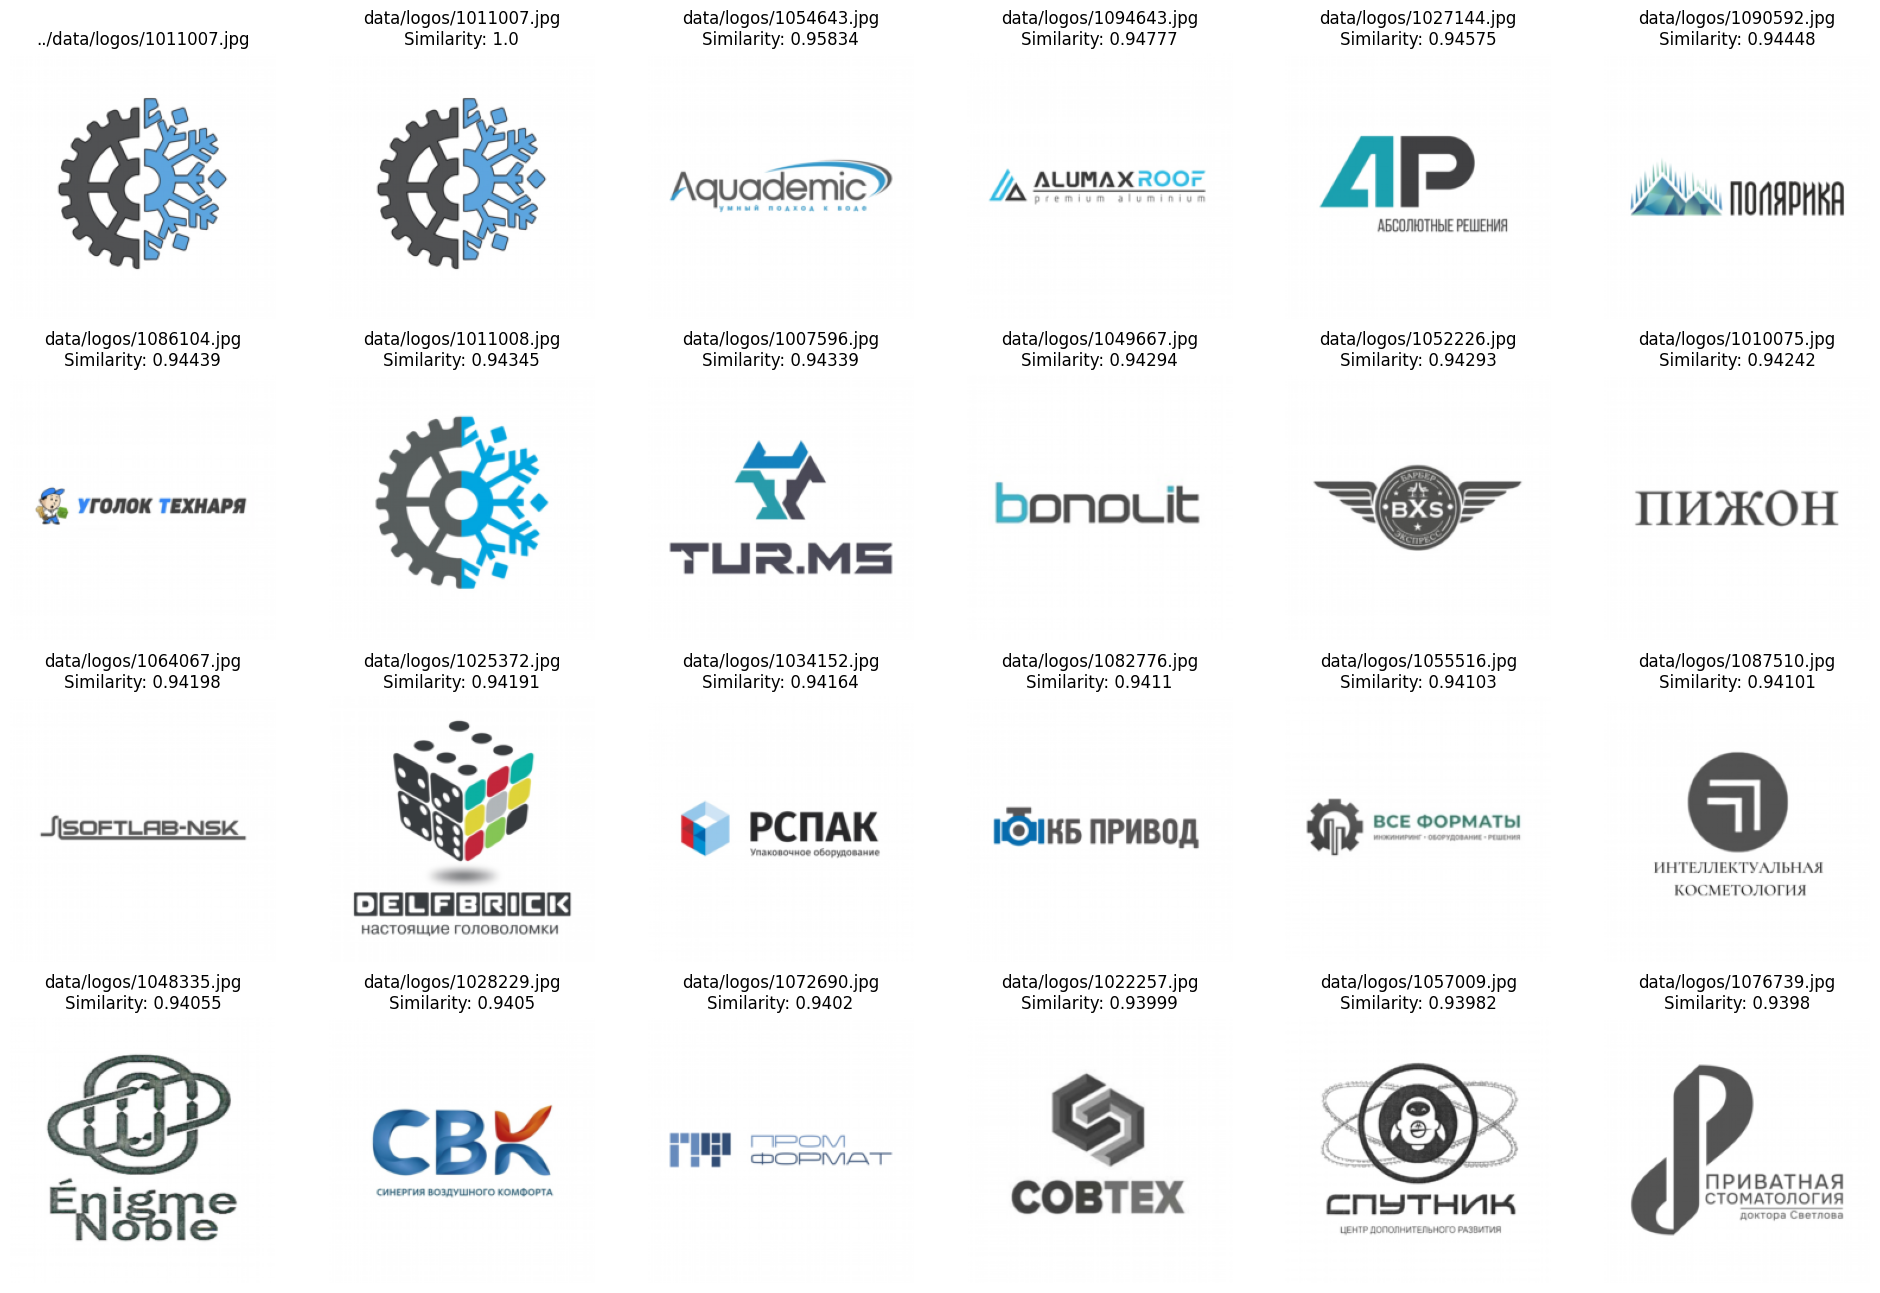

In [51]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
#img_path = '../data/logos/1014250.jpg' # duck sitting at a table
img_path = '../data/logos/1011007.jpg'

similarities = compute_similarity_combined(img_path, [0.0, 1.0])
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = embeddings_paths[idx]
            img = load_image('../' + path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()

100%|██████████| 100000/100000 [00:21<00:00, 4736.64it/s]


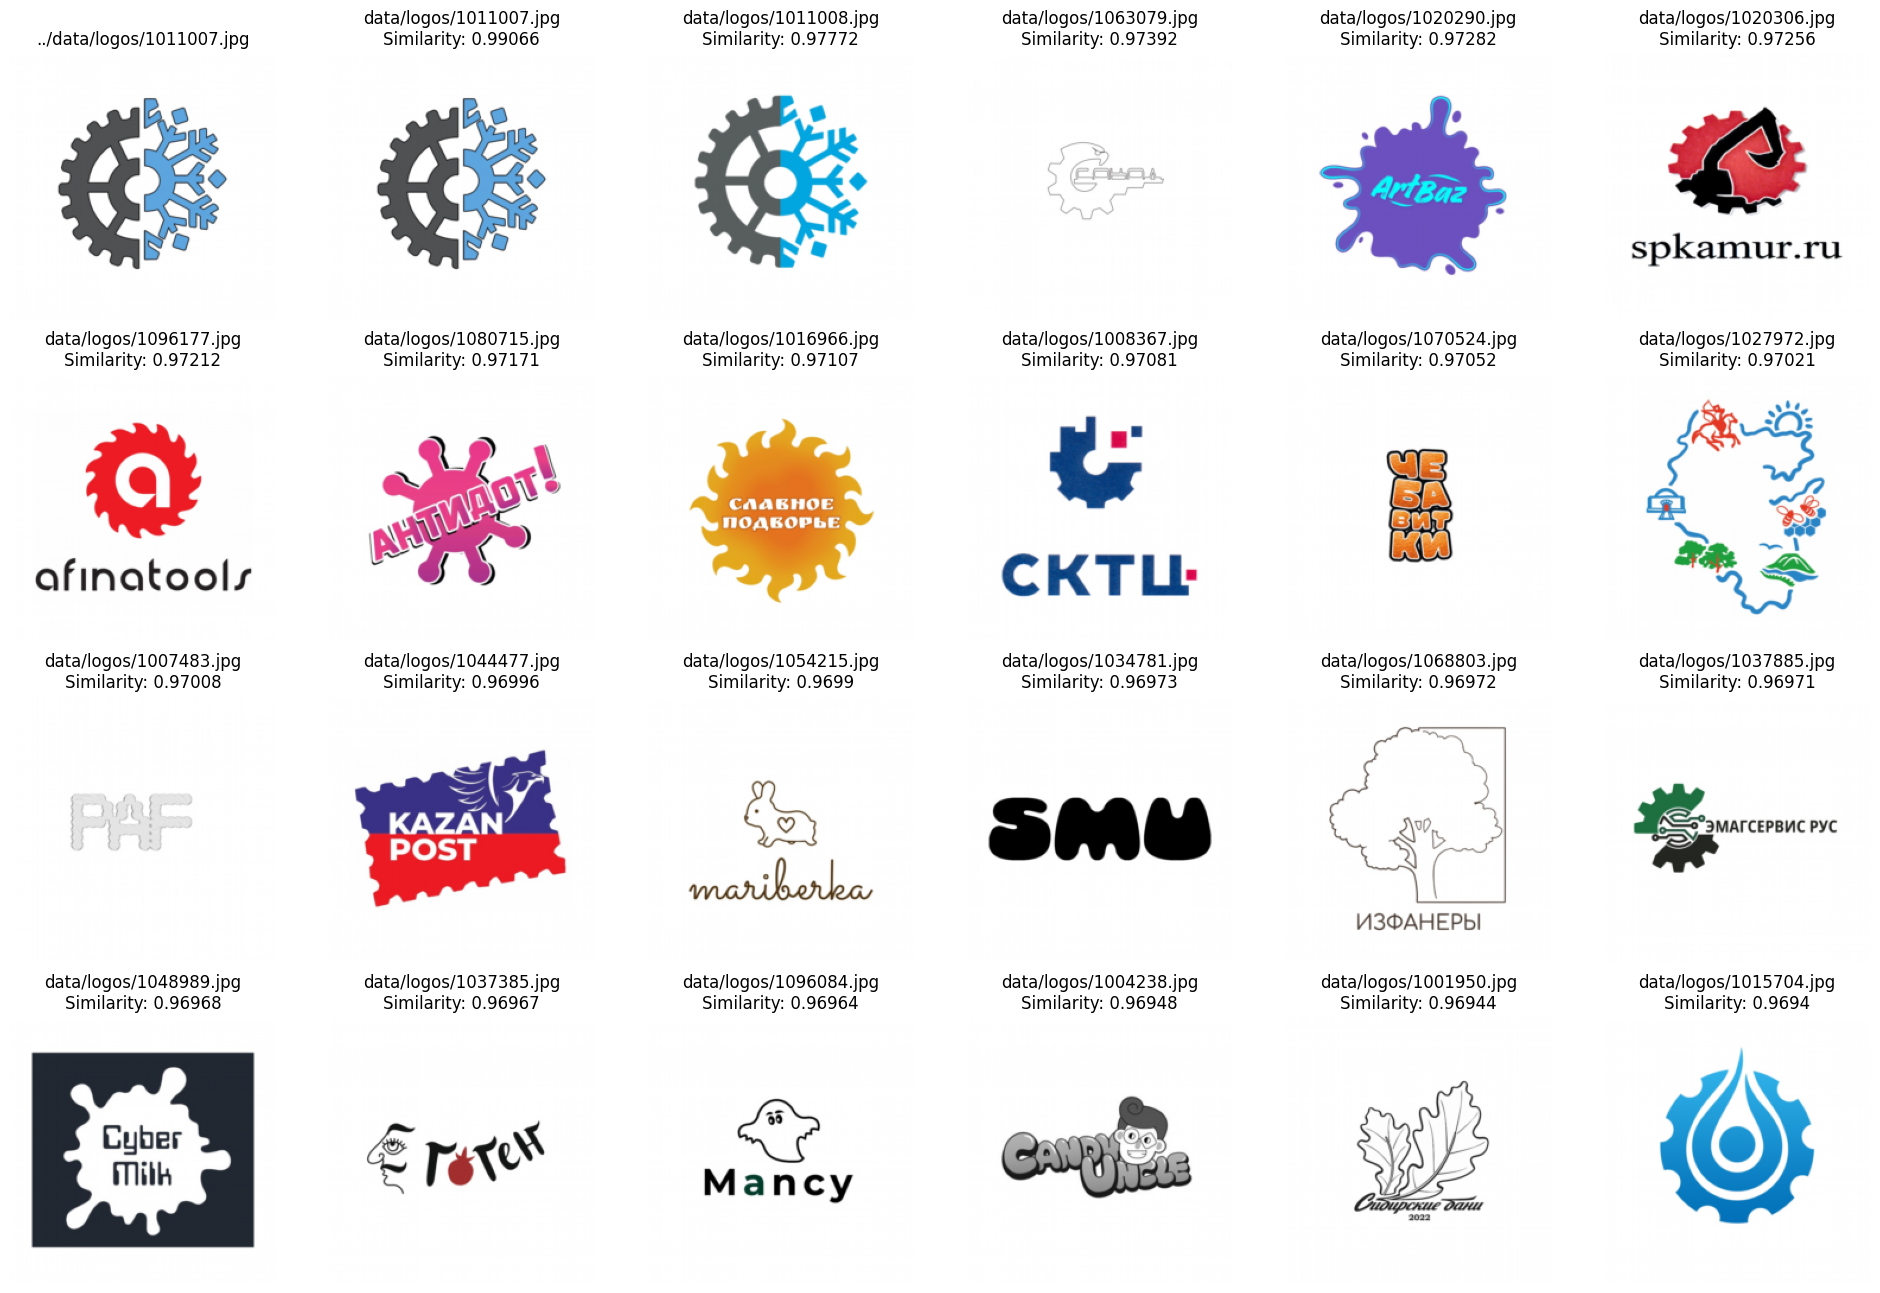

In [56]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
#img_path = '../data/logos/1014250.jpg' # duck sitting at a table
img_path = '../data/logos/1011007.jpg'

similarities = compute_similarity_combined(img_path, [0.97, 0.03])
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = embeddings_paths[idx]
            img = load_image('../' + path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()